# Multiclass Classification — Softmax Regression

**Goal:** Extend logistic regression to $K > 2$ classes. We'll derive the softmax function, categorical cross-entropy loss, and the gradient updates from scratch.

> **Prerequisite:** Logistic regression math (sigmoid, binary cross-entropy, gradient descent).

---

## 1. Problem Setup

Given input $\mathbf{x} \in \mathbb{R}^n$, we want to predict a label $y \in \{1, 2, \ldots, K\}$ across $K$ classes.

We maintain a **weight matrix** $\mathbf{W} \in \mathbb{R}^{K \times n}$ and a **bias vector** $\mathbf{b} \in \mathbb{R}^K$. Each row $\mathbf{w}_k$ is the weight vector for class $k$.

The raw scores (logits) for all $K$ classes are computed in one shot:

$$\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b} \in \mathbb{R}^K$$

where $z_k = \mathbf{w}_k^\top \mathbf{x} + b_k$ is the logit for class $k$.

Again, $z_k \in (-\infty, +\infty)$ — we need to convert these into a **probability distribution** over $K$ classes.

## 2. The Softmax Function

The softmax maps a vector of logits to a valid probability distribution:

$$\boxed{\text{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\displaystyle\sum_{j=1}^{K} e^{z_j}}, \quad k = 1, \ldots, K}$$

### Properties

| Property | Statement |
|---|---|
| Non-negativity | $\hat{y}_k > 0$ for all $k$ |
| Sums to one | $\displaystyle\sum_{k=1}^K \hat{y}_k = 1$ |
| Monotonic | Larger logit $\Rightarrow$ larger probability |
| Translation invariant | $\text{softmax}(\mathbf{z}) = \text{softmax}(\mathbf{z} - c)$ for any constant $c$ |

### Connection to logistic regression

For $K = 2$, softmax reduces exactly to the sigmoid:

$$\hat{y}_1 = \frac{e^{z_1}}{e^{z_1} + e^{z_2}} = \frac{1}{1 + e^{-(z_1 - z_2)}} = \sigma(z_1 - z_2)$$

### Numerical stability

Computing $e^{z_k}$ directly overflows for large $z_k$. We use the translation invariance property with $c = \max_j z_j$:

$$\text{softmax}(\mathbf{z})_k = \frac{e^{z_k - c}}{\displaystyle\sum_{j=1}^{K} e^{z_j - c}}$$

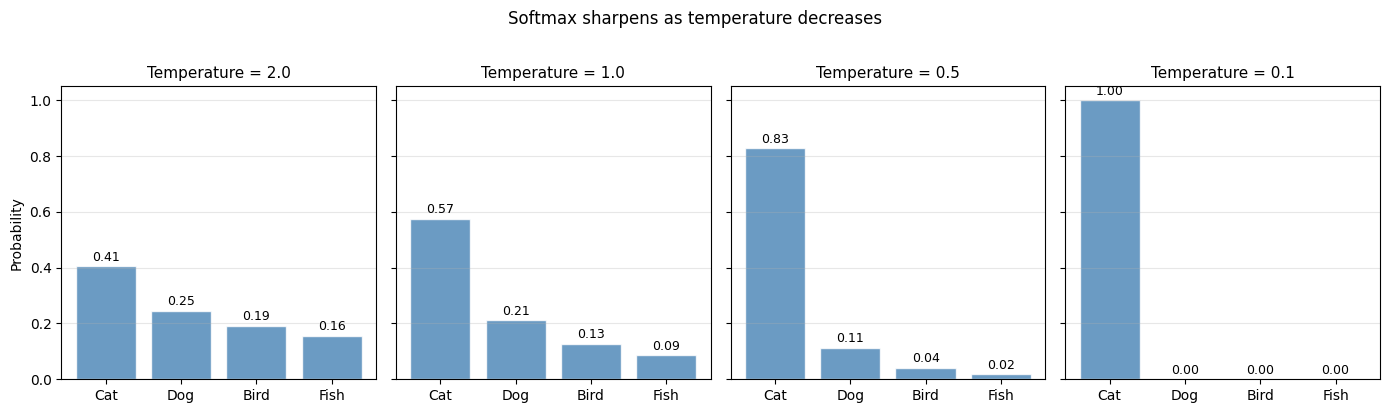

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(z):
    z_shifted = z - np.max(z, axis=-1, keepdims=True)  # numerical stability
    exp_z = np.exp(z_shifted)
    return exp_z / exp_z.sum(axis=-1, keepdims=True)

# Visualize how softmax sharpens with temperature
logits = np.array([2.0, 1.0, 0.5, 0.1])
temperatures = [2.0, 1.0, 0.5, 0.1]
classes = ['Cat', 'Dog', 'Bird', 'Fish']

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, T in zip(axes, temperatures):
    probs = softmax(logits / T)
    bars = ax.bar(classes, probs, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(f'Temperature = {T}', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Probability' if T == 2.0 else '')
    ax.grid(axis='y', alpha=0.3)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{p:.2f}', ha='center', fontsize=9)

plt.suptitle('Softmax sharpens as temperature decreases', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 3. The Model

The full forward pass for a single example $\mathbf{x}$:

$$\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b} \in \mathbb{R}^K$$

$$\hat{\mathbf{y}} = \text{softmax}(\mathbf{z}) \in \mathbb{R}^K$$

where $\hat{y}_k = P(y = k \mid \mathbf{x};\, \mathbf{W}, \mathbf{b})$.

### One-hot encoding

The true label $y$ is encoded as a one-hot vector $\mathbf{e}_y \in \{0,1\}^K$:

$$e_{y,k} = \begin{cases} 1 & \text{if } k = y \\ 0 & \text{otherwise} \end{cases}$$

For example, with $K=4$ and $y=2$: $\mathbf{e}_y = [0,\ 1,\ 0,\ 0]^\top$.

## 4. Loss Function — Categorical Cross-Entropy

The likelihood of the correct class under our model is $\hat{y}_y$. Taking the negative log:

$$\boxed{\mathcal{L}(\hat{\mathbf{y}},\, y) = -\log \hat{y}_y = -\sum_{k=1}^{K} e_{y,k} \log \hat{y}_k}$$

The two forms are equivalent — the sum collapses to one term since $e_{y,k} = 0$ for all $k \neq y$.

### Connection to binary cross-entropy

For $K = 2$, categorical cross-entropy reduces exactly to binary cross-entropy:

$$\mathcal{L} = -[e_{y,0}\log\hat{y}_0 + e_{y,1}\log\hat{y}_1] = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]$$

### Cost over $m$ examples

$$J(\mathbf{W}, \mathbf{b}) = \frac{1}{m} \sum_{i=1}^{m} \mathcal{L}\!\left(\hat{\mathbf{y}}^{(i)},\, y^{(i)}\right) = -\frac{1}{m} \sum_{i=1}^{m} \log \hat{y}^{(i)}_{y^{(i)}}$$

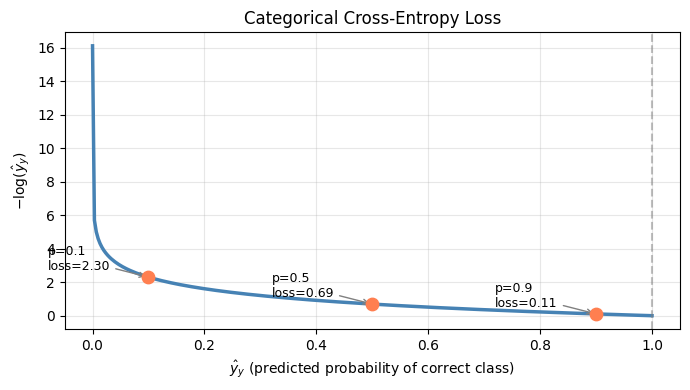

In [2]:
p = np.linspace(1e-7, 1 - 1e-7, 300)
loss = -np.log(p)

plt.figure(figsize=(7, 4))
plt.plot(p, loss, color='steelblue', linewidth=2.5)
plt.axvline(1.0, color='gray', linestyle='--', alpha=0.5)
plt.scatter([0.9, 0.5, 0.1], [-np.log(0.9), -np.log(0.5), -np.log(0.1)],
            color='coral', s=80, zorder=5)
for px, label in [(0.9, 'confident\ncorrect'), (0.5, 'uncertain'), (0.1, 'confident\nwrong')]:
    plt.annotate(f'p={px}\nloss={-np.log(px):.2f}', xy=(px, -np.log(px)),
                 xytext=(px - 0.18, -np.log(px) + 0.4), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='gray', lw=1))
plt.xlabel(r'$\hat{y}_y$ (predicted probability of correct class)')
plt.ylabel(r'$-\log(\hat{y}_y)$')
plt.title('Categorical Cross-Entropy Loss')
plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

## 5. Gradient Derivation

We need $\dfrac{\partial \mathcal{L}}{\partial z_k}$ to backpropagate through the softmax.

### Step 1 — Softmax Jacobian

The softmax is not element-wise — every output $\hat{y}_k$ depends on every input $z_j$. The Jacobian is:

$$\frac{\partial \hat{y}_k}{\partial z_j} = \hat{y}_k\,(\delta_{kj} - \hat{y}_j)$$

where $\delta_{kj}$ is the Kronecker delta ($1$ if $k=j$, else $0$).

### Step 2 — Loss gradient w.r.t. $\hat{y}_k$

$$\frac{\partial \mathcal{L}}{\partial \hat{y}_k} = -\frac{e_{y,k}}{\hat{y}_k}$$

### Step 3 — Chain rule over all $k$

$$\frac{\partial \mathcal{L}}{\partial z_j} = \sum_{k=1}^{K} \frac{\partial \mathcal{L}}{\partial \hat{y}_k} \cdot \frac{\partial \hat{y}_k}{\partial z_j}
= \sum_{k=1}^{K} \left(-\frac{e_{y,k}}{\hat{y}_k}\right) \hat{y}_k(\delta_{kj} - \hat{y}_j)$$

$$= \sum_{k=1}^{K} -e_{y,k}(\delta_{kj} - \hat{y}_j)
= -e_{y,j} + \hat{y}_j \underbrace{\sum_{k=1}^{K} e_{y,k}}_{=\,1}$$

$$\boxed{\frac{\partial \mathcal{L}}{\partial z_j} = \hat{y}_j - e_{y,j}}$$

In vector form:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{z}} = \hat{\mathbf{y}} - \mathbf{e}_y$$

> Exactly the same form as logistic regression: **prediction minus ground truth**. The Jacobian complexity vanishes entirely.

## 6. Gradients w.r.t. Weights and Biases

From $\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}$, by chain rule:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}} \cdot \mathbf{x}^\top = (\hat{\mathbf{y}} - \mathbf{e}_y)\,\mathbf{x}^\top \in \mathbb{R}^{K \times n}$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{b}} = \hat{\mathbf{y}} - \mathbf{e}_y \in \mathbb{R}^K$$

### Averaged over $m$ examples

$$\frac{\partial J}{\partial \mathbf{W}} = \frac{1}{m}\,(\hat{\mathbf{Y}} - \mathbf{E})^\top \mathbf{X} \in \mathbb{R}^{K \times n}$$

$$\frac{\partial J}{\partial \mathbf{b}} = \frac{1}{m}\sum_{i=1}^{m}(\hat{\mathbf{y}}^{(i)} - \mathbf{e}_{y^{(i)}}) \in \mathbb{R}^K$$

where $\hat{\mathbf{Y}} \in \mathbb{R}^{m \times K}$ is the matrix of predicted probabilities and $\mathbf{E} \in \mathbb{R}^{m \times K}$ is the one-hot label matrix.

### Update rules

$$\mathbf{W} := \mathbf{W} - \alpha \cdot \frac{\partial J}{\partial \mathbf{W}}$$

$$\mathbf{b} := \mathbf{b} - \alpha \cdot \frac{\partial J}{\partial \mathbf{b}}$$

## 7. Regularization

### L2 (Ridge)

$$J(\mathbf{W}, \mathbf{b}) = \frac{1}{m}\sum_{i=1}^{m} \mathcal{L}^{(i)} + \frac{\lambda}{2m}\|\mathbf{W}\|_F^2$$

where $\|\mathbf{W}\|_F^2 = \displaystyle\sum_{k,j} W_{kj}^2$ is the Frobenius norm squared.

Modified gradient:

$$\frac{\partial J}{\partial \mathbf{W}} = \frac{1}{m}\,(\hat{\mathbf{Y}} - \mathbf{E})^\top \mathbf{X} + \frac{\lambda}{m}\mathbf{W}$$

## 8. Full Implementation from Scratch

In [3]:
import numpy as np

class SoftmaxRegression:
    def __init__(self, lr=0.1, n_iter=500, lam=0.0):
        self.lr     = lr
        self.n_iter = n_iter
        self.lam    = lam
        self.W      = None   # (K, n)
        self.b      = None   # (K,)
        self.losses = []

    def softmax(self, z):
        z_shifted = z - z.max(axis=1, keepdims=True)  # numerical stability
        exp_z = np.exp(z_shifted)
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    def one_hot(self, y, K):
        E = np.zeros((len(y), K))
        E[np.arange(len(y)), y] = 1
        return E

    def loss(self, Y_hat, E):
        m   = len(E)
        eps = 1e-9
        ce  = -np.mean(np.sum(E * np.log(Y_hat + eps), axis=1))
        reg = (self.lam / (2 * m)) * np.sum(self.W ** 2)
        return ce + reg

    def fit(self, X, y):
        m, n = X.shape
        K    = len(np.unique(y))
        self.W = np.zeros((K, n))
        self.b = np.zeros(K)
        E = self.one_hot(y, K)           # (m, K) one-hot labels

        for _ in range(self.n_iter):
            Z     = X @ self.W.T + self.b        # (m, K)  logits
            Y_hat = self.softmax(Z)              # (m, K)  probabilities
            delta = Y_hat - E                   # (m, K)  ∂L/∂z = ŷ - e_y

            dW = (delta.T @ X) / m + (self.lam / m) * self.W   # (K, n)
            db = delta.mean(axis=0)                             # (K,)

            self.W -= self.lr * dW
            self.b -= self.lr * db

            self.losses.append(self.loss(Y_hat, E))

    def predict_proba(self, X):
        Z = X @ self.W.T + self.b
        return self.softmax(Z)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

Test accuracy: 0.908


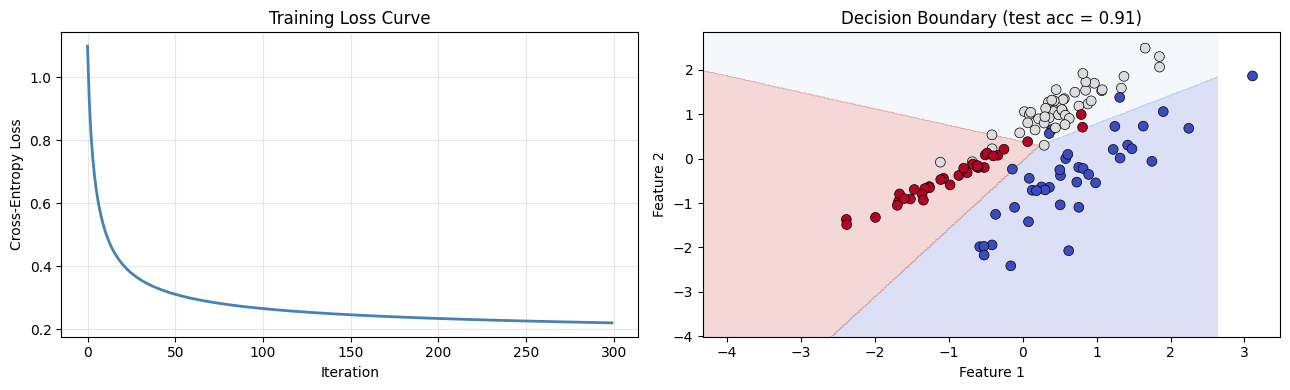

In [4]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=600, n_features=2, n_redundant=0,
                            n_informative=2, n_classes=3, n_clusters_per_class=1,
                            random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model = SoftmaxRegression(lr=0.5, n_iter=300)
model.fit(X_train, y_train)

acc = accuracy_score(y_test, model.predict(X_test))
print(f"Test accuracy: {acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curve
axes[0].plot(model.losses, color='steelblue', linewidth=2)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss Curve'); axes[0].grid(alpha=0.3)

# Decision boundary
xx, yy = np.meshgrid(np.linspace(X_train[:,0].min()-0.5, X_train[:,0].max()+0.5, 300),
                     np.linspace(X_train[:,1].min()-0.5, X_train[:,1].max()+0.5, 300))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
scatter = axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test,
                          cmap='coolwarm', edgecolors='k', linewidths=0.5, s=50)
axes[1].set_title(f'Decision Boundary (test acc = {acc:.2f})')
axes[1].set_xlabel('Feature 1'); axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

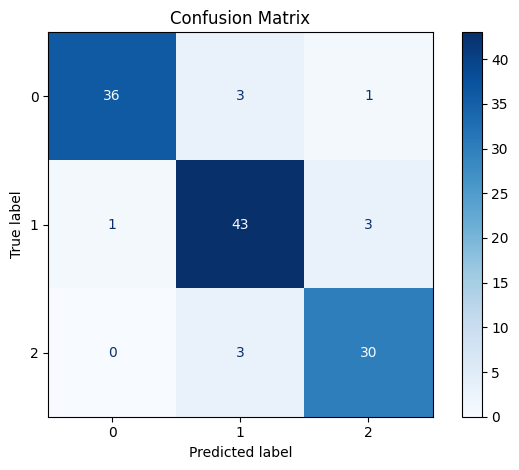

In [5]:
cm = confusion_matrix(y_test, model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix'); plt.tight_layout(); plt.show()

## 9. Logistic vs Softmax — Side-by-Side

| | Logistic Regression | Softmax Regression |
|---|---|---|
| Classes | $K = 2$ | $K \geq 2$ |
| Parameters | $\mathbf{w} \in \mathbb{R}^n,\ b \in \mathbb{R}$ | $\mathbf{W} \in \mathbb{R}^{K \times n},\ \mathbf{b} \in \mathbb{R}^K$ |
| Activation | $\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}$ | $\hat{y}_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$ |
| Loss | $-[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ | $-\log \hat{y}_y = -\sum_k e_{y,k}\log\hat{y}_k$ |
| Key gradient | $\hat{y} - y$ | $\hat{\mathbf{y}} - \mathbf{e}_y$ |
| Decision boundary | 1 hyperplane | $K$ hyperplanes |

> Softmax regression is a strict generalization. Setting $K=2$ recovers logistic regression exactly.

## 10. Summary Cheat Sheet

| Step | Formula |
|---|---|
| Logits | $\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b} \in \mathbb{R}^K$ |
| Softmax | $\hat{y}_k = \dfrac{e^{z_k}}{\displaystyle\sum_j e^{z_j}}$ |
| Stable softmax | $\hat{y}_k = \dfrac{e^{z_k - c}}{\displaystyle\sum_j e^{z_j - c}},\quad c = \max_j z_j$ |
| Loss | $\mathcal{L} = -\log\hat{y}_y$ |
| Key gradient | $\dfrac{\partial\mathcal{L}}{\partial\mathbf{z}} = \hat{\mathbf{y}} - \mathbf{e}_y$ |
| Weight gradient | $\dfrac{\partial J}{\partial \mathbf{W}} = \dfrac{1}{m}\,(\hat{\mathbf{Y}} - \mathbf{E})^\top \mathbf{X}$ |
| Bias gradient | $\dfrac{\partial J}{\partial \mathbf{b}} = \dfrac{1}{m}\displaystyle\sum_i(\hat{\mathbf{y}}^{(i)} - \mathbf{e}_{y^{(i)}})$ |

---

### Key intuitions

- Softmax is a **smooth argmax** — as logits grow apart, it approaches a one-hot distribution.
- The gradient $\hat{\mathbf{y}} - \mathbf{e}_y$ means: **push down the wrong classes, push up the correct one**.
- The decision boundaries are $K$ linear hyperplanes — one per class — making this still a linear classifier.
- Cross-entropy loss has no penalty for confident correct predictions ($\hat{y}_y \to 1 \Rightarrow \mathcal{L} \to 0$), but is unbounded for confident wrong ones.